# Math for IT

This notebook will be used for the development part.

The development will be done using Test Driven Development which is a common practice in software development.

For this purpose a wrapper named `nose2` of the python `unittest` built-in tool will be used so install it using `pip` or `conda`.

🚫 **No Numpy** 🚫

In [1]:
pip install nose2

Note: you may need to restart the kernel to use updated packages.


## Warm Up!

Let's try the testing framework!

Now implement a function `hello` which returns `"hello"` and try the workflow.

In [2]:
#export
#this cell will be tested
def hello():
    return "hello"

In [3]:
#this cell will not be tested
def hello():
    return "hello"

In [4]:
!python ./runTests.py

--- converting lib notebook into lib ---
--- done ---
--- converting test notebook into test file ---
--- done ---
.....
----------------------------------------------------------------------
Ran 5 tests in 0.000s

OK


## Enter the matrix

**This part will be done without any other library than the python built-ins**

The goal is to implement a 2D matrix structure, with operations(multiplication, addition, transposition,...) and types' properties(diagonal, square, identity,...) related to it.

You can find some of the operations and types of matrices [here](https://en.wikipedia.org/wiki/Matrix_(mathematics)).

🎯 Implement a method `init_mat(nrows, ncols)` which will return a 2D matrix initialized with zeros or random values.

In [5]:
#export
def init_mat(nrows, ncols):
    return [[0 for _ in range(ncols)] for _ in range(nrows)]

🎯 Implement a method `add(mat1, mat2)` which takes two matrices and returns the sum of them.

In [6]:
#export
def add(mat1,mat2):
    if len(mat1)==len(mat2) and len(mat1[0])==len(mat2[0]):
        sum=init_mat(len(mat1),len(mat2[0]))
        for i in range (len(mat1)):
            for j in range (len(mat2[0])):
                sum[i][j]=mat1[i][j]+mat2[i][j]
        return sum
    else:
        raise Exception("Sorry, Matrix are not equals") 
    

🎯 Implement a method `mul(mat1, mat2)` which takes two matrices and returns their multiplication.

In [7]:
#export
def mul(mat1, mat2):
    if len(mat1[0]) == len(mat2):
        product = init_mat(len(mat1), len(mat2[0]))
        for i in range(len(mat1)):
            for j in range(len(mat2[0])):
                for k in range(len(mat2)):
                    product[i][j] = product[i][j]+ mat1[i][k] * mat2[k][j]
        return product
    else:
        raise Exception("Sorry, Product can't be done")


### To go further: pack it in a class (optional)


Implement a method `scalar_product(scalar, mat)` which takes a scalar and a matrix and return the scalar product of them.

In [8]:
#export
def scalar_product(scalar, mat):
    scalar_prod=init_mat(len(mat),len(mat[0]))
    for i in range(len(mat)):
        for j in range (len(mat[0])):
            scalar_prod[i][j]=scalar * mat[i][j]
    return scalar_prod

Implement a method `transpose(mat)` which takes a matrix and returns its transposition.

Implement the following methods :
- `is_identity(m)` which takes a matrix `m` and returns `True` if `m` is an identity matrix.
- `is_diagonal(m)` which takes a matrix `m` and returns `True` if `m` is a diagonal matrix.
- `is_square(m)` which takes a matrix `m` and returns `True` if `m` is a square matrix.

you can also implement other properties like : `is_scalar_matrix`, `is_column_matrix`, `is_row_matrix`,...

Now implement a `trace(mat)` which return the trace of the matrix passed in parameters.

🔥🔥 Implement a class `Matrix` using the `mul` and `add` functions as basic operators. Try to test it.

Etape 1 Préparation des calculs

In [9]:
import time

In [10]:
import random

def init_mat_rnd(nrows, ncols, random_init=False):
    if random_init:
        return [[random.random() for _ in range(ncols)] for _ in range(nrows)]
    else:
        return [[0 for _ in range(ncols)] for _ in range(nrows)]


Matrice 10 * 10

In [11]:
def addition_temps(mat1, mat2):
    start = time.time()
    addition = add(mat1, mat2)
    end = time.time()
    elapsed = end - start
    print(f"Temps d'exécution addition: {elapsed:.6f} seconds")
    return elapsed

def multiplication_temps(mat1, mat2):
    start = time.time()
    multiplication = mul(mat1, mat2)
    end = time.time()
    elapsed = end - start
    print(f"Temps d'exécution multiplication: {elapsed:.6f} seconds")
    return elapsed

In [12]:
add_result_naive = []
mul_result_naive = []

# Test pour différentes tailles de matrices
sizes = [10, 100, 1000]

for size in sizes:
    print(f'Matrice {size}x{size}')
    mat1 = init_mat_rnd(size, size, random_init=True)
    mat2 = init_mat_rnd(size, size, random_init=True)
    add_result_naive.append(addition_temps(mat1, mat2))
    mul_result_naive.append(multiplication_temps(mat1, mat2))

Matrice 10x10
Temps d'exécution addition: 0.000049 seconds
Temps d'exécution multiplication: 0.000354 seconds
Matrice 100x100
Temps d'exécution addition: 0.001107 seconds
Temps d'exécution multiplication: 0.094280 seconds
Matrice 1000x1000
Temps d'exécution addition: 0.129364 seconds
Temps d'exécution multiplication: 106.020690 seconds


In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def addition_temps_numpy(mat1, mat2):
    start = time.time()
    addition = (mat1 + mat2)
    end = time.time()
    elapsed = end - start
    print(f"Temps d'exécution addition: {elapsed:.6f} seconds")
    return elapsed

def multiplication_temps_numpy(mat1, mat2):
    start = time.time()
    multiplication = np.dot(mat1 , mat2)
    end = time.time()
    elapsed = end - start
    print(f"Temps d'exécution multiplication: {elapsed:.6f} seconds")
    return elapsed

In [15]:
add_result_numpy = []
mul_result_numpy = []

# Test pour différentes tailles de matrices
sizes = [10, 100, 1000, 2000, 5000, 8000, 10000]

for size in sizes:
    print(f'Matrice {size}x{size}')
    mat1 = np.random.rand(size, size)
    mat2 = np.random.rand(size, size)
    add_result_numpy.append(addition_temps_numpy(mat1, mat2))
    mul_result_numpy.append(multiplication_temps_numpy(mat1, mat2))


Matrice 10x10
Temps d'exécution addition: 0.000026 seconds
Temps d'exécution multiplication: 0.000056 seconds
Matrice 100x100
Temps d'exécution addition: 0.000013 seconds
Temps d'exécution multiplication: 0.000156 seconds
Matrice 1000x1000
Temps d'exécution addition: 0.003725 seconds
Temps d'exécution multiplication: 0.017178 seconds
Matrice 2000x2000
Temps d'exécution addition: 0.007652 seconds
Temps d'exécution multiplication: 0.103599 seconds
Matrice 5000x5000
Temps d'exécution addition: 0.043846 seconds
Temps d'exécution multiplication: 1.439854 seconds
Matrice 8000x8000
Temps d'exécution addition: 0.115045 seconds
Temps d'exécution multiplication: 7.602843 seconds
Matrice 10000x10000
Temps d'exécution addition: 0.180030 seconds
Temps d'exécution multiplication: 13.056324 seconds


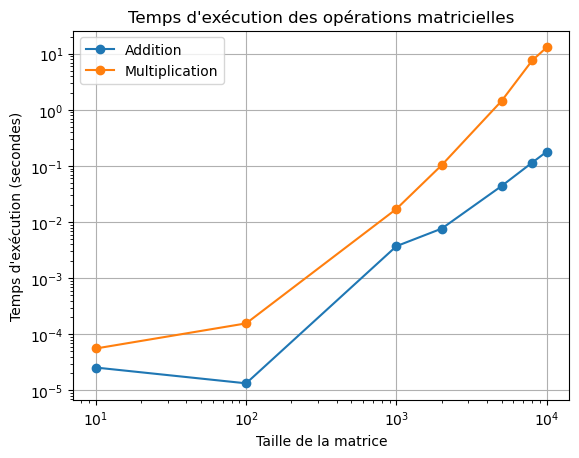

In [16]:

# Traçage des résultats
plt.plot(sizes, add_result_numpy, label='Addition',marker='o')
plt.plot(sizes, mul_result_numpy, label='Multiplication',marker='o')
plt.xlabel('Taille de la matrice')
plt.ylabel('Temps d\'exécution (secondes)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.title('Temps d\'exécution des opérations matricielles')
plt.legend()
plt.show()

In [17]:
import time
import numpy as np
from numba import jit

# Addition optimisée avec Numba
@jit
def addition_jit(mat1, mat2):
    return mat1 + mat2

# Multiplication optimisée avec Numba
@jit
def multiplication_jit(mat1, mat2):
    return np.dot(mat1, mat2)

# Fonction pour mesurer le temps d'exécution
def measure_time(func, mat1, mat2):
    start = time.time()
    result = func(mat1, mat2)
    end = time.time()
    return end - start, result

# Warmup avec vérification NumPy
size = 10
mat1 = np.random.rand(size, size)
mat2 = np.random.rand(size, size)

# Résultats avec NumPy
numpy_add = np.add(mat1, mat2)
numpy_mul = np.dot(mat1, mat2)

# Warmup avec Numba et validation
_, jit_add = measure_time(addition_jit, mat1, mat2)
_, jit_mul = measure_time(multiplication_jit, mat1, mat2)

# Vérification des résultats
assert np.allclose(jit_add, numpy_add), "Addition : Résultat différent entre NumPy et Numba"
assert np.allclose(jit_mul, numpy_mul), "Multiplication : Résultat différent entre NumPy et Numba"

print("Warmup terminé : les résultats Numba et NumPy sont identiques.")

# Tailles des matrices à tester
sizes = [10, 100, 1000, 2000, 5000, 8000, 10000]  # Limitez selon la mémoire disponible

# Résultats pour addition et multiplication
add_result_jit = []
mul_result_jit = []

# Boucle pour mesurer les temps d'exécution
for size in sizes:
    mat1 = np.random.rand(size, size)
    mat2 = np.random.rand(size, size)
    
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    
    # Mesure du temps pour l'addition
    add_time, _ = measure_time(addition_jit, mat1, mat2)
    add_result_jit.append(add_time)
    
    # Mesure du temps pour la multiplication
    mul_time, _ = measure_time(multiplication_jit, mat1, mat2)
    mul_result_jit.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats de @jit :")
print("Addition :", add_result_jit)
print("Multiplication :", mul_result_jit)


Warmup terminé : les résultats Numba et NumPy sont identiques.
Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...
Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...
Fin pour la taille 10000x10000.

Résultats de @jit :
Addition : [6.67572021484375e-06, 2.0265579223632812e-05, 0.003563404083251953, 0.021097421646118164, 0.1282193660736084, 0.32586097717285156, 0.5132029056549072]
Multiplication : [4.291534423828125e-06, 0.00012063980102539062, 0.013400554656982422, 0.09421396255493164, 1.4326088428497314, 7.5771238803863525, 13.1

In [18]:
import numpy as np
import time
from numba import njit

# Addition optimized with Numba
@njit
def addition_njit(mat1, mat2):
    return mat1 + mat2

# Multiplication optimized with Numba 
@njit
def multiplication_njit(mat1, mat2):
    return np.dot(mat1, mat2)

# Function to measure execution time
def measure_time(func, mat1, mat2):
    start = time.time()
    result = func(mat1, mat2)
    end = time.time()
    return end - start, result

# Warmup with NumPy verification
size = 10
mat1 = np.random.rand(size, size)
mat2 = np.random.rand(size, size)

# Results with NumPy
numpy_add = np.add(mat1, mat2)
numpy_mul = np.dot(mat1, mat2)

# Warmup with Numba and validation
_, njit_add = measure_time(addition_njit, mat1, mat2)
_, njit_mul = measure_time(multiplication_njit, mat1, mat2)

# Vérification des résultats
assert np.allclose(njit_add, numpy_add), "Addition : Résultat différent entre NumPy et Numba"
assert np.allclose(njit_mul, numpy_mul), "Multiplication : Résultat différent entre NumPy et Numba"

print("Warmup terminé : les résultats Numba et NumPy sont identiques.")


# Results for addition and multiplication
add_result_njit = []
mul_result_njit = []

# Loop to measure execution times
for size in sizes:
    mat1 = np.random.rand(size, size)
    mat2 = np.random.rand(size, size)
    
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    
    # Measure time for addition
    add_time, _ = measure_time(addition_njit, mat1, mat2)
    add_result_njit.append(add_time)
    
    # Measure time for multiplication
    mul_time, _ = measure_time(multiplication_njit, mat1, mat2)
    mul_result_njit.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Display the results
print("\nRésultats de @njit :")
print("Addition :", add_result_njit)
print("Multiplication :", mul_result_njit)


Warmup terminé : les résultats Numba et NumPy sont identiques.
Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...
Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...
Fin pour la taille 10000x10000.

Résultats de @njit :
Addition : [6.67572021484375e-06, 1.621246337890625e-05, 0.003599882125854492, 0.02114701271057129, 0.1278226375579834, 0.3269827365875244, 0.5144641399383545]
Multiplication : [4.0531158447265625e-06, 0.00011801719665527344, 0.013410329818725586, 0.09376335144042969, 1.4369099140167236, 7.577081680297852, 13.250

In [19]:
import numpy as np
import time
from numba import vectorize, float64, njit

# Numba vectorized function for addition
@vectorize([float64(float64, float64)], target='parallel')
def addition_vectorize(a, b):
    return a + b

# Numba optimized function for multiplication
@njit
def multiplication_vectorize(a, b):
    return np.dot(a, b)

# Function to measure execution time
def measure_time(func, mat1, mat2):
    start = time.time()
    result = func(mat1, mat2)
    end = time.time()
    return end - start, result

# Warmup with NumPy verification
size = 10
mat1 = np.random.rand(size, size)
mat2 = np.random.rand(size, size)

# NumPy results
numpy_add = np.add(mat1, mat2)
numpy_mul = np.dot(mat1, mat2)

# Warmup and validation with Numba
_, vectorize_add = measure_time(addition_vectorize, mat1, mat2)
_, vectorize_mul = measure_time(multiplication_vectorize, mat1, mat2)

# Vérification des résultats
assert np.allclose(vectorize_add, numpy_add), "Addition : Résultat différent entre NumPy et Numba"
assert np.allclose(vectorize_mul, numpy_mul), "Multiplication : Résultat différent entre NumPy et Numba"

print("Warmup terminé : les résultats Numba et NumPy sont identiques.")


# Résultats pour addition et multiplication
add_result_vectorize = []
mul_result_vectorize = []

# Boucle pour mesurer les temps d'exécution
for size in sizes:
    mat1 = np.random.rand(size, size)
    mat2 = np.random.rand(size, size)
    
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    
    # Measure time for addition
    add_time, _ = measure_time(addition_vectorize, mat1, mat2)
    add_result_vectorize.append(add_time)
    
    # Measure time for multiplication
    mul_time, _ = measure_time(multiplication_vectorize, mat1, mat2)
    mul_result_vectorize.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats de @vectorize et @njit :")
print("Addition :", add_result_vectorize)
print("Multiplication :", mul_result_vectorize)


Warmup terminé : les résultats Numba et NumPy sont identiques.
Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...
Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...
Fin pour la taille 10000x10000.

Résultats de @vectorize et @njit :
Addition : [0.0001900196075439453, 3.337860107421875e-05, 0.0012576580047607422, 0.00708770751953125, 0.04290628433227539, 0.10290241241455078, 0.17055869102478027]
Multiplication : [8.821487426757812e-06, 0.0001418590545654297, 0.013339519500732422, 0.09816789627075195, 1.4521467685699463, 7.558069

In [20]:
import numpy as np
import time
from numba import cuda

# CUDA kernel for matrix addition
@cuda.jit
def addition_cuda(mat1, mat2, result):
    i, j = cuda.grid(2)  # 2D thread indexing
    if i < result.shape[0] and j < result.shape[1]:
        result[i, j] = mat1[i, j] + mat2[i, j]

# CUDA kernel for matrix multiplication
@cuda.jit
def multiplication_cuda(mat1, mat2, result):
    i, j = cuda.grid(2)  # 2D thread indexing
    if i < result.shape[0] and j < result.shape[1]:
        temp = 0
        for k in range(mat1.shape[1]):
            temp += mat1[i, k] * mat2[k, j]
        result[i, j] = temp

# Function to measure execution time
def measure_time_cuda(func, mat1, mat2, result):
    start = time.time()
    func[blocks_per_grid, threads_per_block](mat1, mat2, result)  # Launch kernel
    cuda.synchronize()  # Wait for the GPU to complete execution
    end = time.time()
    return end - start

# Warmup with NumPy verification
size = 10
mat1 = np.random.rand(size, size).astype(np.float32)
mat2 = np.random.rand(size, size).astype(np.float32)

# NumPy results
numpy_add = np.add(mat1, mat2)
numpy_mul = np.matmul(mat1, mat2)

# CUDA warmup
result_add = np.zeros((size, size), dtype=np.float32)
result_mul = np.zeros((size, size), dtype=np.float32)

threads_per_block = (16, 16)
blocks_per_grid = (
    (size + threads_per_block[0] - 1) // threads_per_block[0],
    (size + threads_per_block[1] - 1) // threads_per_block[1],
)

# Test addition
addition_cuda[blocks_per_grid, threads_per_block](mat1, mat2, result_add)
assert np.allclose(result_add, numpy_add), "Erreur : Résultats d'addition différents entre CUDA et NumPy"

# Test multiplication
multiplication_cuda[blocks_per_grid, threads_per_block](mat1, mat2, result_mul)
assert np.allclose(result_mul, numpy_mul), "Erreur : Résultats de multiplication différents entre CUDA et NumPy"

print("Warmup terminé : les résultats CUDA et NumPy sont identiques.")


# Results for addition and multiplication
add_result_cuda = []
mul_result_cuda = []

# Loop to measure execution times
for size in sizes:
    mat1 = np.random.rand(size, size).astype(np.float32)
    mat2 = np.random.rand(size, size).astype(np.float32)
    result_add = np.zeros((size, size), dtype=np.float32)
    result_mul = np.zeros((size, size), dtype=np.float32)
    
    # Update CUDA grid dimensions based on matrix size
    blocks_per_grid = (
        (size + threads_per_block[0] - 1) // threads_per_block[0],
        (size + threads_per_block[1] - 1) // threads_per_block[1],
    )
    
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    
    # Measure time for addition
    add_time = measure_time_cuda(addition_cuda, mat1, mat2, result_add)
    add_result_cuda.append(add_time)
    
    # Measure time for multiplication
    mul_time = measure_time_cuda(multiplication_cuda, mat1, mat2, result_mul)
    mul_result_cuda.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Display the results
print("\nRésultats avec CUDA :")
print("Addition :", add_result_cuda)
print("Multiplication :", mul_result_cuda)


/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/cudadrv/devicearray.py:887: NumbaPerformanceWarning: Host array used in CUDA kernel will incur copy overhead to/from device.
  warn(NumbaPerformanceWarning(msg))
/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/cudadrv/devicearray.py:887: NumbaPerformanceWarning: Host array used in CUDA ker

Warmup terminé : les résultats CUDA et NumPy sont identiques.
Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...
Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...
Fin pour la taille 10000x10000.

Résultats avec CUDA :
Addition : [0.001153707504272461, 0.0009386539459228516, 0.004346609115600586, 0.013979673385620117, 0.1777491569519043, 0.4227423667907715, 0.6469235420227051]
Multiplication : [0.0009005069732666016, 0.0009677410125732422, 0.06334137916564941, 0.45096516609191895, 7.028420448303223, 28.530827045440674, 55.39731

In [21]:
import cupy as cp
import numpy as np
import timeit

# Taille des matrices pour le test
sizes = [10, 100, 1000, 2000, 5000, 8000,10000]

# Fonction pour l'addition
def test_addition(mat1,mat2):
    cp.add(mat1, mat2)
    cp.cuda.Stream.null.synchronize()  # Synchronisation après

# Fonction pour la multiplication
def test_multiplication(mat1, mat2):
    cp.matmul(mat1, mat2)
    cp.cuda.Stream.null.synchronize()  # Synchronisation après

# Résultats pour l'addition et la multiplication
add_result_cupy = []
mul_result_cupy = []

# Boucle pour mesurer les temps d'exécution avec timeit
for size in sizes:
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    mat1 = cp.random.rand(size, size, dtype=cp.float32)
    mat2 = cp.random.rand(size, size, dtype=cp.float32)
    # Temps pour l'addition
    add_time = timeit.timeit(lambda: test_addition(mat1, mat2), number=1)
    add_result_cupy.append(add_time)

    # Temps pour la multiplication
    mul_time = timeit.timeit(lambda: test_multiplication(mat1, mat2), number=1)
    mul_result_cupy.append(mul_time)

    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats avec CuPy et timeit :")
print("Addition :", add_result_cupy)
print("Multiplication :", mul_result_cupy)


Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...
Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...
Fin pour la taille 10000x10000.

Résultats avec CuPy et timeit :
Addition : [0.0005441000103019178, 5.5564974900335073e-05, 0.000229495984967798, 0.001041668001562357, 0.008318657986819744, 0.022178507002536207, 0.022785816981922835]
Multiplication : [0.035506634041666985, 0.004012245044577867, 0.0010946259717456996, 0.006711321999318898, 0.1867157369852066, 0.7777891549631022, 2.5388904470019042]


In [22]:
import math
from numba import cuda, float32
# Controls threads per block and shared memory usage.
# The computation will be done on blocks of TPBxTPB elements.
# TPB should not be larger than 32 in this example


TPB = 16

# Fonction pour mesurer le temps d'exécution
def measure_time_cuda(func, *args):
    start = time.time()
    func[blockspergrid, threadsperblock](*args)
    cuda.synchronize()  # Synchronisation GPU
    end = time.time()
    return end - start


@cuda.jit
def f(a, b, c):
    x, y = cuda.grid(2)

    if x < c.shape[0] and y < c.shape[1]:
        c[x, y] = a[x, y] + b[x, y]

@cuda.jit
def fast_matmul(A, B, C):

    """
    Perform matrix multiplication of C = A * B using CUDA shared memory.
    Reference: https://stackoverflow.com/a/64198479/13697228 by @RobertCrovella
    """

    # Define an array in the shared memory
    # The size and type of the arrays must be known at compile time
    sA = cuda.shared.array(shape=(TPB, TPB), dtype=float32)
    sB = cuda.shared.array(shape=(TPB, TPB), dtype=float32)

    x, y = cuda.grid(2)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    bpg = cuda.gridDim.x    # blocks per grid

    # Each thread computes one element in the result matrix.
    # The dot product is chunked into dot products of TPB-long vectors.
    tmp = float32(0.)
    for i in range(bpg):
        # Preload data into shared memory
        sA[ty, tx] = 0
        sB[ty, tx] = 0
        if y < A.shape[0] and (tx + i * TPB) < A.shape[1]:
            sA[ty, tx] = A[y, tx + i * TPB]
        if x < B.shape[1] and (ty + i * TPB) < B.shape[0]:
            sB[ty, tx] = B[ty + i * TPB, x]

        # Wait until all threads finish preloading
        cuda.syncthreads()

        # Computes partial product on the shared memory
        for j in range(TPB):
            tmp += sA[ty, j] * sB[j, tx]

        # Wait until all threads finish computing
        cuda.syncthreads()
    if y < C.shape[0] and x < C.shape[1]:
        C[y, x] = tmp

# Warmup pour addition et multiplication, avec vérification
size = 10
x_h = np.random.rand(size, size).astype(np.float32)
y_h = np.random.rand(size, size).astype(np.float32)

# Résultats avec NumPy
numpy_add_result = np.add(x_h, y_h)
numpy_mul_result = np.matmul(x_h, y_h)

# Résultats avec CUDA
x_d, y_d = cuda.to_device(x_h), cuda.to_device(y_h)
z_d_add, z_d_mul = cuda.device_array((size, size), dtype=np.float32), cuda.device_array((size, size), dtype=np.float32)

# Configuration des blocs et grilles
threadsperblock = (TPB, TPB)
blockspergrid = (math.ceil(size / threadsperblock[0]), math.ceil(size / threadsperblock[1]))

# Addition CUDA
f[blockspergrid, threadsperblock](x_d, y_d, z_d_add)
z_h_add = z_d_add.copy_to_host()

# Multiplication CUDA
fast_matmul[blockspergrid, threadsperblock](x_d, y_d, z_d_mul)
z_h_mul = z_d_mul.copy_to_host()

# Vérification des résultats
assert np.allclose(numpy_add_result, z_h_add), "Addition : Résultat différent entre NumPy et CUDA"
assert np.allclose(numpy_mul_result, z_h_mul), "Multiplication : Résultat différent entre NumPy et CUDA"

print("Warmup terminé : les résultats CUDA et NumPy sont identiques.")

add_result_cuda2 = []
mul_result_cuda2 = []
sizes=[10,100,1000,2000,5000,8000,10000]
for size in sizes:
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")

    # Initialisation des matrices
    x_h = np.random.rand(size, size).astype(np.float32)
    y_h = np.random.rand(size, size).astype(np.float32)
    z_h_add = np.zeros((size, size), dtype=np.float32)
    z_h_mul = np.zeros((size, size), dtype=np.float32)
    

    x_d = cuda.to_device(x_h)
    y_d = cuda.to_device(y_h)
    z_d_add = cuda.to_device(z_h_add)
    z_d_mul = cuda.to_device(z_h_mul)

    # Configuration des blocs et grilles (2D)
    threadsperblock = (TPB, TPB)
    blockspergrid_x = math.ceil(size / threadsperblock[0])
    blockspergrid_y = math.ceil(size / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # Mesure du temps pour l'addition
    add_time = measure_time_cuda(f, x_d, y_d, z_d_add)
    add_result_cuda2.append(add_time)

    # Mesure du temps pour la multiplication
    mul_time = measure_time_cuda(fast_matmul, x_d, y_d, z_d_mul)
    mul_result_cuda2.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats avec Cuda recodé :")
print("Addition :", add_result_cuda2)
print("Multiplication :", mul_result_cuda2)

/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Warmup terminé : les résultats CUDA et NumPy sont identiques.
Calcul en cours pour les matrices de taille 10x10...
Fin pour la taille 10x10.
Calcul en cours pour les matrices de taille 100x100...
Fin pour la taille 100x100.
Calcul en cours pour les matrices de taille 1000x1000...
Fin pour la taille 1000x1000.
Calcul en cours pour les matrices de taille 2000x2000...
Fin pour la taille 2000x2000.
Calcul en cours pour les matrices de taille 5000x5000...


/home/thibaud.garnier@Digital-Grenoble.local/anaconda3/envs/keras_gpu/lib/python3.12/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Fin pour la taille 5000x5000.
Calcul en cours pour les matrices de taille 8000x8000...
Fin pour la taille 8000x8000.
Calcul en cours pour les matrices de taille 10000x10000...


CudaAPIError: [2] Call to cuMemAlloc results in CUDA_ERROR_OUT_OF_MEMORY

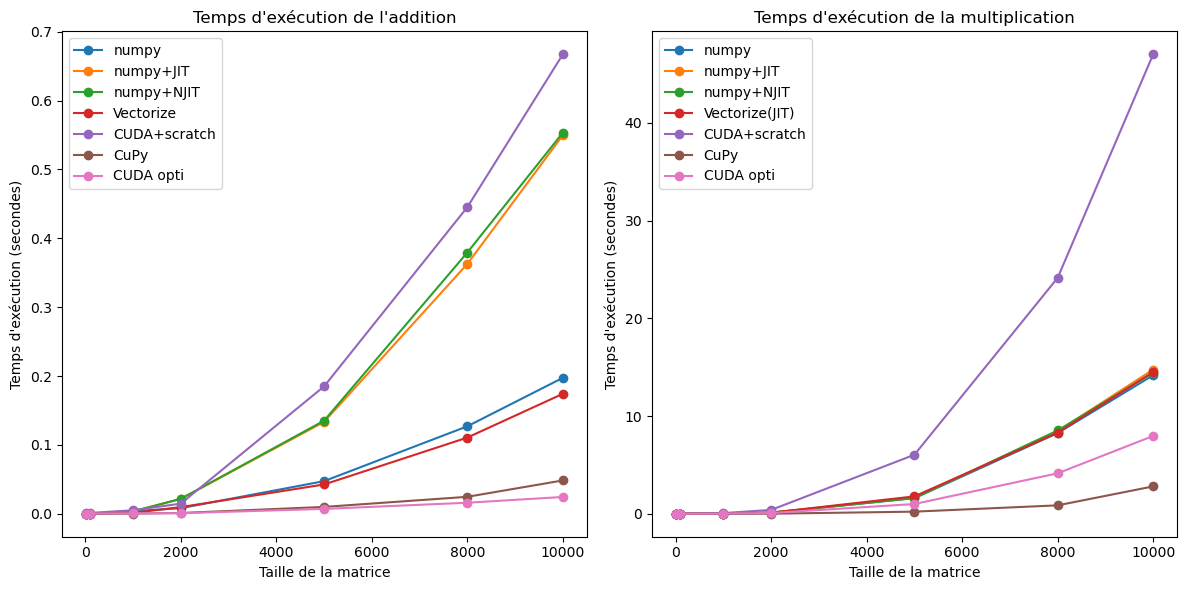

In [ ]:
import matplotlib.pyplot as plt

# Traçage des résultats
plt.figure(figsize=(12, 6))

# Addition
plt.subplot(1, 2, 1)
plt.plot(sizes, add_result_numpy, label='numpy', marker='o')
plt.plot(sizes, add_result_jit, label='numpy+JIT', marker='o')
plt.plot(sizes, add_result_njit, label='numpy+NJIT', marker='o')
plt.plot(sizes, add_result_vectorize, label='Vectorize', marker='o')
plt.plot(sizes, add_result_cuda, label='CUDA+scratch', marker='o')
plt.plot(sizes, add_result_cupy, label='CuPy', marker='o')
plt.plot(sizes, add_result_cuda2, label='CUDA opti', marker='o')
plt.xlabel('Taille de la matrice')
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Temps d'exécution de l'addition")
plt.legend()

# Multiplication
plt.subplot(1, 2, 2)
plt.plot(sizes, mul_result_numpy, label='numpy', marker='o')
plt.plot(sizes, mul_result_jit, label='numpy+JIT', marker='o')
plt.plot(sizes, mul_result_njit, label='numpy+NJIT', marker='o')
plt.plot(sizes, mul_result_vectorize, label='Vectorize(JIT)', marker='o')
plt.plot(sizes, mul_result_cuda, label='CUDA+scratch', marker='o')
plt.plot(sizes, mul_result_cupy, label='CuPy', marker='o')
plt.plot(sizes, mul_result_cuda2, label='CUDA opti', marker='o')
plt.xlabel('Taille de la matrice')
plt.ylabel("Temps d'exécution (secondes)")
plt.title("Temps d'exécution de la multiplication")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import cupy as cp
import numpy as np
import timeit

# Taille des matrices pour le test
sizes = [10, 100, 1000, 2000, 5000, 8000]

# Fonction pour l'addition
def test_addition(mat1,mat2):
    cp.add(mat1, mat2)
    cp.cuda.Stream.null.synchronize()  # Synchronisation après

# Fonction pour la multiplication
def test_multiplication(mat1, mat2):
    cp.matmul(mat1, mat2)
    cp.cuda.Stream.null.synchronize()  # Synchronisation après

# Résultats pour l'addition et la multiplication
add_result_cupy = []
mul_result_cupy = []

# Boucle pour mesurer les temps d'exécution avec timeit
for size in sizes:
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")
    mat1 = cp.random.rand(size, size, dtype=cp.float32)
    mat2 = cp.random.rand(size, size, dtype=cp.float32)
    
    # Temps pour l'addition
    add_time = timeit.timeit(lambda: test_addition(mat1, mat2), number=1)
    add_result_cupy.append(add_time)

    # Temps pour la multiplication
    mul_time = timeit.timeit(lambda: test_multiplication(mat1, mat2), number=1)
    mul_result_cupy.append(mul_time)

    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats avec CuPy et timeit :")
print("Addition :", add_result_cupy)
print("Multiplication :", mul_result_cupy)


In [ ]:
import math
from numba import cuda, float32
# Controls threads per block and shared memory usage.
# The computation will be done on blocks of TPBxTPB elements.
# TPB should not be larger than 32 in this example


TPB = 16

# Fonction pour mesurer le temps d'exécution
def measure_time_cuda(func, *args):
    start = time.time()
    func[blockspergrid, threadsperblock](*args)
    cuda.synchronize()  # Synchronisation GPU
    end = time.time()
    return end - start


@cuda.jit
def f(a, b, c):
    x, y = cuda.grid(2)

    if x < c.shape[0] and y < c.shape[1]:
        c[x, y] = a[x, y] + b[x, y]

@cuda.jit
def fast_matmul(A, B, C):

    """
    Perform matrix multiplication of C = A * B using CUDA shared memory.
    Reference: https://stackoverflow.com/a/64198479/13697228 by @RobertCrovella
    """

    # Define an array in the shared memory
    # The size and type of the arrays must be known at compile time
    sA = cuda.shared.array(shape=(TPB, TPB), dtype=float32)
    sB = cuda.shared.array(shape=(TPB, TPB), dtype=float32)

    x, y = cuda.grid(2)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y
    bpg = cuda.gridDim.x    # blocks per grid

    # Each thread computes one element in the result matrix.
    # The dot product is chunked into dot products of TPB-long vectors.
    tmp = float32(0.)
    for i in range(bpg):
        # Preload data into shared memory
        sA[ty, tx] = 0
        sB[ty, tx] = 0
        if y < A.shape[0] and (tx + i * TPB) < A.shape[1]:
            sA[ty, tx] = A[y, tx + i * TPB]
        if x < B.shape[1] and (ty + i * TPB) < B.shape[0]:
            sB[ty, tx] = B[ty + i * TPB, x]

        # Wait until all threads finish preloading
        cuda.syncthreads()

        # Computes partial product on the shared memory
        for j in range(TPB):
            tmp += sA[ty, j] * sB[j, tx]

        # Wait until all threads finish computing
        cuda.syncthreads()
    if y < C.shape[0] and x < C.shape[1]:
        C[y, x] = tmp

# Warmup pour addition et multiplication, avec vérification
size = 10
x_h = np.random.rand(size, size).astype(np.float32)
y_h = np.random.rand(size, size).astype(np.float32)

# Résultats avec NumPy
numpy_add_result = np.add(x_h, y_h)
numpy_mul_result = np.matmul(x_h, y_h)

# Résultats avec CUDA
x_d, y_d = cuda.to_device(x_h), cuda.to_device(y_h)
z_d_add, z_d_mul = cuda.device_array((size, size), dtype=np.float32), cuda.device_array((size, size), dtype=np.float32)

# Configuration des blocs et grilles
threadsperblock = (TPB, TPB)
blockspergrid = (math.ceil(size / threadsperblock[0]), math.ceil(size / threadsperblock[1]))

# Addition CUDA
f[blockspergrid, threadsperblock](x_d, y_d, z_d_add)
z_h_add = z_d_add.copy_to_host()

# Multiplication CUDA
fast_matmul[blockspergrid, threadsperblock](x_d, y_d, z_d_mul)
z_h_mul = z_d_mul.copy_to_host()

# Vérification des résultats
assert np.allclose(numpy_add_result, z_h_add), "Addition : Résultat différent entre NumPy et CUDA"
assert np.allclose(numpy_mul_result, z_h_mul), "Multiplication : Résultat différent entre NumPy et CUDA"

print("Warmup terminé : les résultats CUDA et NumPy sont identiques.")

add_result_cuda2 = []
mul_result_cuda2 = []
sizes=[10,100,1000,2000,5000,8000,10000]
for size in sizes:
    print(f"Calcul en cours pour les matrices de taille {size}x{size}...")

    # Initialisation des matrices
    x_h = np.random.rand(size, size).astype(np.float32)
    y_h = np.random.rand(size, size).astype(np.float32)
    z_h_add = np.zeros((size, size), dtype=np.float32)
    z_h_mul = np.zeros((size, size), dtype=np.float32)
    

    x_d = cuda.to_device(x_h)
    y_d = cuda.to_device(y_h)
    z_d_add = cuda.to_device(z_h_add)
    z_d_mul = cuda.to_device(z_h_mul)

    # Configuration des blocs et grilles (2D)
    threadsperblock = (TPB, TPB)
    blockspergrid_x = math.ceil(size / threadsperblock[0])
    blockspergrid_y = math.ceil(size / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    # Mesure du temps pour l'addition
    add_time = measure_time_cuda(f, x_d, y_d, z_d_add)
    add_result_cuda2.append(add_time)

    # Mesure du temps pour la multiplication
    mul_time = measure_time_cuda(fast_matmul, x_d, y_d, z_d_mul)
    mul_result_cuda2.append(mul_time)
    
    print(f"Fin pour la taille {size}x{size}.")

# Affichage des résultats
print("\nRésultats avec Cuda recodé :")
print("Addition :", add_result_cuda2)
print("Multiplication :", mul_result_cuda2)